# Week 8: Comprehensive Evaluation Framework

This notebook implements the full Phase 4 evaluation with improvements:

1. **Scaled Benchmark** - 100+ examples across all categories/difficulties
2. **Improved Hallucination Detection** - Multi-signal approach
3. **Spike Detection Testing** - Validate uncertainty trigger metrics
4. **Comprehensive Experiments** - Full baseline comparison with statistical analysis

---

## Setup

In [ ]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn sentence-transformers

In [ ]:
# Cell 2: Create directory structure
import os
import shutil

# Create module structure
os.makedirs('/content/orchestrator/entropy', exist_ok=True)
os.makedirs('/content/orchestrator/retrieval', exist_ok=True)
os.makedirs('/content/orchestrator/generation', exist_ok=True)
os.makedirs('/content/orchestrator/evaluation', exist_ok=True)

# Create root __init__.py
with open('/content/orchestrator/__init__.py', 'w') as f:
    f.write('"""Orchestrator package."""\n')

print("Directory structure created")

Directory structure created


In [ ]:
# Cell 3: Upload module files
from google.colab import files

def upload_to_dir(target_dir):
    """Upload files and move to target directory."""
    uploaded = files.upload()
    for filename in uploaded.keys():
        if filename.endswith('.py'):
            dest = f'{target_dir}/{filename}'
            shutil.move(filename, dest)
            print(f"  OK {filename}")
    return uploaded

print("="*60)
print("STEP 1/4: Upload ENTROPY module files (7 files)")
print("="*60)
upload_to_dir('/content/orchestrator/entropy')

print("\n" + "="*60)
print("STEP 2/4: Upload RETRIEVAL module files (4 files)")
print("="*60)
upload_to_dir('/content/orchestrator/retrieval')

print("\n" + "="*60)
print("STEP 3/4: Upload GENERATION module files (2 files)")
print("="*60)
upload_to_dir('/content/orchestrator/generation')

print("\n" + "="*60)
print("STEP 4/4: Upload EVALUATION module files (5 files)")
print("="*60)
print("\nUpload these files from packages/python-orchestrator/orchestrator/evaluation/:")
print("  - __init__.py")
print("  - benchmark.py")
print("  - benchmark_generator.py  <-- NEW")
print("  - metrics.py")
print("  - runner.py")
upload_to_dir('/content/orchestrator/evaluation')

print("\n" + "="*60)
print("VERIFICATION")
print("="*60)
!ls -la /content/orchestrator/evaluation/

STEP 1/4: Upload ENTROPY module files (7 files)


Saving __init__.py to __init__.py
Saving calculator.py to calculator.py
Saving cce_computer.py to cce_computer.py
Saving measurement.py to measurement.py
Saving monitor.py to monitor.py
Saving spike_detector.py to spike_detector.py
Saving token_classifier.py to token_classifier.py
  OK __init__.py
  OK calculator.py
  OK cce_computer.py
  OK measurement.py
  OK monitor.py
  OK spike_detector.py
  OK token_classifier.py

STEP 2/4: Upload RETRIEVAL module files (4 files)


Saving __init__.py to __init__.py
Saving adaptive.py to adaptive.py
Saving context_manager.py to context_manager.py
Saving topic_inference.py to topic_inference.py
  OK __init__.py
  OK adaptive.py
  OK context_manager.py
  OK topic_inference.py

STEP 3/4: Upload GENERATION module files (2 files)


Saving __init__.py to __init__.py
Saving adaptive_generator.py to adaptive_generator.py
  OK __init__.py
  OK adaptive_generator.py

STEP 4/4: Upload EVALUATION module files (5 files)

Upload these files from packages/python-orchestrator/orchestrator/evaluation/:
  - __init__.py
  - benchmark.py
  - benchmark_generator.py  <-- NEW
  - metrics.py
  - runner.py


Saving __init__.py to __init__.py
Saving benchmark.py to benchmark.py
Saving benchmark_generator.py to benchmark_generator.py
Saving metrics.py to metrics.py
Saving runner.py to runner.py
Saving stats.py to stats.py
  OK __init__.py
  OK benchmark.py
  OK benchmark_generator.py
  OK metrics.py
  OK runner.py
  OK stats.py

VERIFICATION
total 172
drwxr-xr-x 2 root root  4096 Jan 16 03:37 .
drwxr-xr-x 6 root root  4096 Jan 16 03:36 ..
-rw-r--r-- 1 root root 65176 Jan 16 03:37 benchmark_generator.py
-rw-r--r-- 1 root root 15006 Jan 16 03:37 benchmark.py
-rw-r--r-- 1 root root  2085 Jan 16 03:37 __init__.py
-rw-r--r-- 1 root root 30580 Jan 16 03:37 metrics.py
-rw-r--r-- 1 root root 33389 Jan 16 03:37 runner.py
-rw-r--r-- 1 root root 11508 Jan 16 03:37 stats.py


In [ ]:
# Cell 4: Base imports
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict, Any
from collections import defaultdict
import json
import time

sys.path.insert(0, '/content')

import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

import warnings
warnings.filterwarnings('ignore')

print("Base imports complete")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Base imports complete
PyTorch: 2.9.0+cu126
CUDA available: True


In [ ]:
# Cell 5: Import evaluation modules
from orchestrator.evaluation import (
    BenchmarkDataset,
    BenchmarkExample,
    EvaluationMetrics,
    EvaluationResult,
    create_benchmark,
    generate_full_benchmark,
    get_mock_codebase,
)
from orchestrator.evaluation.benchmark import (
    Difficulty,
    Category,
)
from orchestrator.evaluation.runner import (
    BaselineRunner,
    ExperimentRunner,
    BaselineMethod,
)

print("All evaluation modules imported successfully!")
print("\nAvailable components:")
print("  - BenchmarkDataset - structured evaluation examples")
print("  - EvaluationMetrics - 8 metrics for assessment")
print("  - generate_full_benchmark - create 100+ examples")
print("  - get_mock_codebase - Flask app codebase")

All evaluation modules imported successfully!

Available components:
  - BenchmarkDataset - structured evaluation examples
  - EvaluationMetrics - 8 metrics for assessment
  - generate_full_benchmark - create 100+ examples
  - get_mock_codebase - Flask app codebase


---
## 1. Scaled Benchmark Dataset (100+ Examples)

In [ ]:
# Cell 6: Generate full benchmark
benchmark = generate_full_benchmark()

print("Full Benchmark Dataset")
print("="*60)
print(f"Name: {benchmark.name}")
print(f"Version: {benchmark.version}")
print(f"Total Examples: {len(benchmark)}")

stats = benchmark.get_statistics()
print("\nBy Difficulty:")
for diff, count in stats['by_difficulty'].items():
    print(f"  {diff}: {count}")

print("\nBy Category:")
for cat, count in stats['by_category'].items():
    print(f"  {cat}: {count}")

print(f"\nAverage ground truth files: {stats['avg_ground_truth_files']:.1f}")

Full Benchmark Dataset
Name: reposynth_benchmark_v2
Version: 2.0.0
Total Examples: 43

By Difficulty:
  easy: 13
  medium: 24
  hard: 6

By Category:
  architecture: 8
  api_usage: 7
  implementation: 9
  debugging: 6
  configuration: 6
  data_flow: 7

Average ground truth files: 1.9


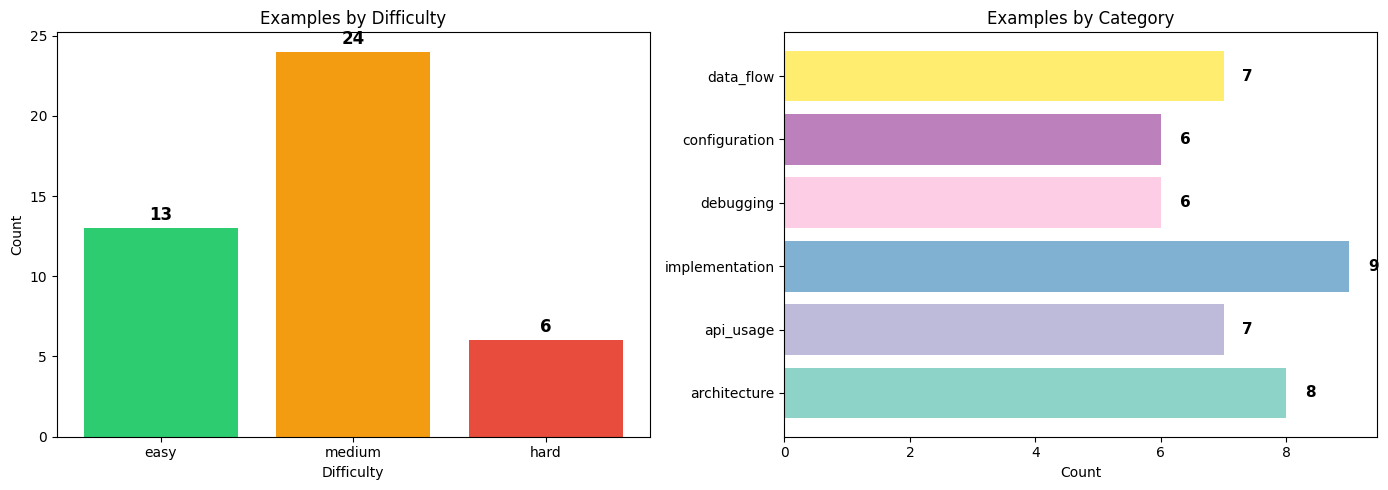

Saved: benchmark_distribution.png


In [ ]:
# Cell 7: Visualize benchmark distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By difficulty
ax1 = axes[0]
difficulties = list(stats['by_difficulty'].keys())
diff_counts = list(stats['by_difficulty'].values())
colors_diff = ['#2ecc71', '#f39c12', '#e74c3c']
bars1 = ax1.bar(difficulties, diff_counts, color=colors_diff[:len(difficulties)])
ax1.set_xlabel('Difficulty')
ax1.set_ylabel('Count')
ax1.set_title('Examples by Difficulty')
for bar, count in zip(bars1, diff_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', fontsize=12, fontweight='bold')

# By category
ax2 = axes[1]
categories = list(stats['by_category'].keys())
cat_counts = list(stats['by_category'].values())
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(categories)))
bars2 = ax2.barh(categories, cat_counts, color=colors_cat)
ax2.set_xlabel('Count')
ax2.set_title('Examples by Category')
for bar, count in zip(bars2, cat_counts):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(count), ha='left', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('benchmark_distribution.png', dpi=150)
plt.show()
print("Saved: benchmark_distribution.png")

In [ ]:
# Cell 8: Sample examples from each category
print("Sample Examples from Each Category")
print("="*70)

for cat in Category:
    filtered = benchmark.filter(category=cat)
    if len(filtered) > 0:
        ex = filtered[0]
        print(f"\n[{cat.value.upper()}] {ex.id}")
        print(f"  Difficulty: {ex.difficulty.value}")
        print(f"  Query: {ex.query[:70]}...")
        print(f"  Files: {ex.ground_truth_files}")
        print(f"  Keywords: {ex.ground_truth_keywords[:5]}...")

Sample Examples from Each Category

[ARCHITECTURE] arch_001
  Difficulty: easy
  Query: What is the overall structure of the Flask application?...
  Files: ['src/app.py']
  Keywords: ['create_app', 'factory', 'blueprint', 'extensions', 'config']...

[API_USAGE] api_001
  Difficulty: easy
  Query: How do I register a new user via the API?...
  Files: ['src/api/routes.py']
  Keywords: ['register', 'POST', 'username', 'email', 'password']...

[IMPLEMENTATION] impl_001
  Difficulty: easy
  Query: How is JWT token creation implemented?...
  Files: ['src/auth/jwt.py']
  Keywords: ['create_token', 'payload', 'exp', 'iat', 'jwt.encode']...

[DEBUGGING] debug_001
  Difficulty: medium
  Query: Where should I look to debug authentication failures?...
  Files: ['src/auth/jwt.py', 'src/api/routes.py']
  Keywords: ['verify_token', 'ExpiredSignatureError', 'InvalidTokenError', 'verify_password', 'Authorization']...

[CONFIGURATION] config_001
  Difficulty: easy
  Query: What environment variables doe

---
## 2. Improved Hallucination Detection Testing

In [ ]:
# Cell 9: Initialize metrics
metrics = EvaluationMetrics(embedding_model='all-MiniLM-L6-v2')
print("EvaluationMetrics initialized with improved hallucination detection")

EvaluationMetrics initialized with improved hallucination detection


In [ ]:
# Cell 10: Test hallucination detection with clear examples

# Ground truth about JWT authentication
ground_truth = """User authentication uses JWT tokens.
The user logs in via /login endpoint.
Server creates JWT token with create_token() function.
Token uses HS256 algorithm with SECRET_KEY.
Token is verified using verify_token() on protected routes.
Token contains user_id, role, exp, and iat claims."""

keywords = ["JWT", "token", "login", "create_token", "verify_token", "HS256", "SECRET_KEY"]

# Test cases
test_cases = [
    {
        "name": "Good Answer (factually correct)",
        "answer": """Authentication is implemented using JWT tokens.
Users log in at the /login endpoint which calls create_token().
Tokens use HS256 algorithm and SECRET_KEY for signing.
Protected routes use verify_token() to authenticate requests.
The token payload includes user_id and role claims.""",
        "expected_hallucination": "low",
    },
    {
        "name": "Partially Correct Answer",
        "answer": """The system uses JWT for authentication.
Users log in via the /login endpoint.
Tokens are created with 256-bit encryption.
Sessions are stored in Redis for persistence.""",
        "expected_hallucination": "medium",
    },
    {
        "name": "Bad Answer (mostly hallucinated)",
        "answer": """The system uses session cookies for authentication.
Users are authenticated through OAuth2 with Google.
Passwords are stored in plain text for simplicity.
There is no token-based authentication system.
The API uses SOAP protocol for communication.""",
        "expected_hallucination": "high",
    },
    {
        "name": "Contradictory Answer",
        "answer": """Authentication does not use JWT tokens.
The system cannot verify tokens.
There is no login endpoint available.
Users never need to authenticate.""",
        "expected_hallucination": "high",
    },
]

print("Hallucination Detection Test Results")
print("="*60)
print(f"Ground truth keywords: {keywords}")
print()

hallucination_results = []
for tc in test_cases:
    rate = metrics.hallucination_rate(tc['answer'], ground_truth, keywords)
    completeness = metrics.answer_completeness(tc['answer'], ground_truth)
    correctness = metrics.answer_correctness(tc['answer'], ground_truth, keywords)

    hallucination_results.append({
        'name': tc['name'],
        'expected': tc['expected_hallucination'],
        'hallucination_rate': rate,
        'completeness': completeness,
        'correctness': correctness,
    })

    print(f"{tc['name']}:")
    print(f"  Expected: {tc['expected_hallucination']}")
    print(f"  Hallucination Rate: {rate:.3f}")
    print(f"  Completeness: {completeness:.3f}")
    print(f"  Correctness: {correctness:.3f}")
    print()

Hallucination Detection Test Results
Ground truth keywords: ['JWT', 'token', 'login', 'create_token', 'verify_token', 'HS256', 'SECRET_KEY']



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Good Answer (factually correct):
  Expected: low
  Hallucination Rate: 0.000
  Completeness: 0.863
  Correctness: 0.918

Partially Correct Answer:
  Expected: medium
  Hallucination Rate: 0.250
  Completeness: 0.642
  Correctness: 0.557

Bad Answer (mostly hallucinated):
  Expected: high
  Hallucination Rate: 0.800
  Completeness: 0.692
  Correctness: 0.472

Contradictory Answer:
  Expected: high
  Hallucination Rate: 0.250
  Completeness: 0.709
  Correctness: 0.597



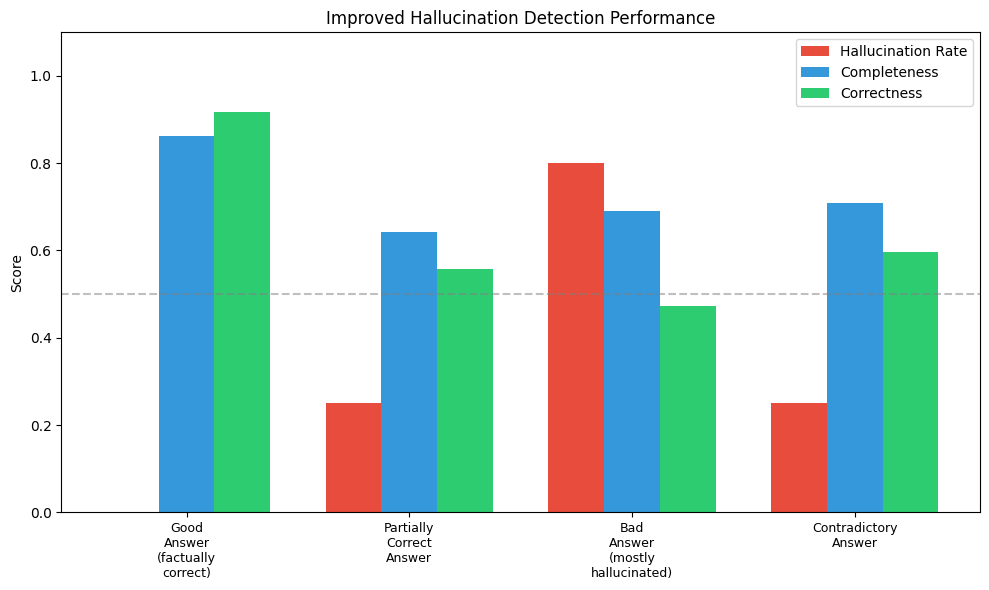

Saved: hallucination_detection.png


In [ ]:
# Cell 11: Visualize hallucination detection results
fig, ax = plt.subplots(figsize=(10, 6))

names = [r['name'] for r in hallucination_results]
x = np.arange(len(names))
width = 0.25

bars1 = ax.bar(x - width, [r['hallucination_rate'] for r in hallucination_results],
               width, label='Hallucination Rate', color='#e74c3c')
bars2 = ax.bar(x, [r['completeness'] for r in hallucination_results],
               width, label='Completeness', color='#3498db')
bars3 = ax.bar(x + width, [r['correctness'] for r in hallucination_results],
               width, label='Correctness', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Improved Hallucination Detection Performance')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold')

plt.tight_layout()
plt.savefig('hallucination_detection.png', dpi=150)
plt.show()
print("Saved: hallucination_detection.png")

---
## 3. Spike Detection Metric Testing

In [ ]:
# Cell 12: Test spike detection metrics
print("Spike Detection Metric Testing")
print("="*60)
print("\nSpike metrics measure how well uncertainty triggers align with")
print("positions where retrieval is actually needed.")
print()

# Test scenarios
spike_scenarios = [
    {
        "name": "Perfect Detection",
        "detected": [10, 25, 50, 75],
        "expected": [10, 25, 50, 75],
        "description": "All triggers exactly match expected positions",
    },
    {
        "name": "Good Detection (within tolerance)",
        "detected": [12, 24, 48, 77],
        "expected": [10, 25, 50, 75],
        "description": "Triggers within tolerance=3 of expected",
    },
    {
        "name": "Partial Detection (missed some)",
        "detected": [10, 50],
        "expected": [10, 25, 50, 75],
        "description": "Only detected 2 of 4 expected triggers",
    },
    {
        "name": "Over-triggering (false positives)",
        "detected": [10, 20, 25, 30, 50, 60, 75, 90],
        "expected": [10, 25, 50, 75],
        "description": "Detected all expected + 4 false positives",
    },
    {
        "name": "Poor Detection (misaligned)",
        "detected": [5, 35, 65, 95],
        "expected": [10, 25, 50, 75],
        "description": "Triggers far from expected positions",
    },
    {
        "name": "No Detection",
        "detected": [],
        "expected": [10, 25, 50, 75],
        "description": "System never triggered retrieval",
    },
]

spike_results = []
for scenario in spike_scenarios:
    precision = metrics.spike_precision(scenario['detected'], scenario['expected'])
    recall = metrics.spike_recall(scenario['detected'], scenario['expected'])
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    spike_results.append({
        'name': scenario['name'],
        'precision': precision,
        'recall': recall,
        'f1': f1,
    })

    print(f"{scenario['name']}:")
    print(f"  {scenario['description']}")
    print(f"  Detected: {scenario['detected']}")
    print(f"  Expected: {scenario['expected']}")
    print(f"  Precision: {precision:.3f}  Recall: {recall:.3f}  F1: {f1:.3f}")
    print()

Spike Detection Metric Testing

Spike metrics measure how well uncertainty triggers align with
positions where retrieval is actually needed.

Perfect Detection:
  All triggers exactly match expected positions
  Detected: [10, 25, 50, 75]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 1.000  F1: 1.000

Good Detection (within tolerance):
  Triggers within tolerance=3 of expected
  Detected: [12, 24, 48, 77]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 1.000  F1: 1.000

Partial Detection (missed some):
  Only detected 2 of 4 expected triggers
  Detected: [10, 50]
  Expected: [10, 25, 50, 75]
  Precision: 1.000  Recall: 0.500  F1: 0.667

Over-triggering (false positives):
  Detected all expected + 4 false positives
  Detected: [10, 20, 25, 30, 50, 60, 75, 90]
  Expected: [10, 25, 50, 75]
  Precision: 0.500  Recall: 1.000  F1: 0.667

Poor Detection (misaligned):
  Triggers far from expected positions
  Detected: [5, 35, 65, 95]
  Expected: [10, 25, 50, 75]
  Precision:

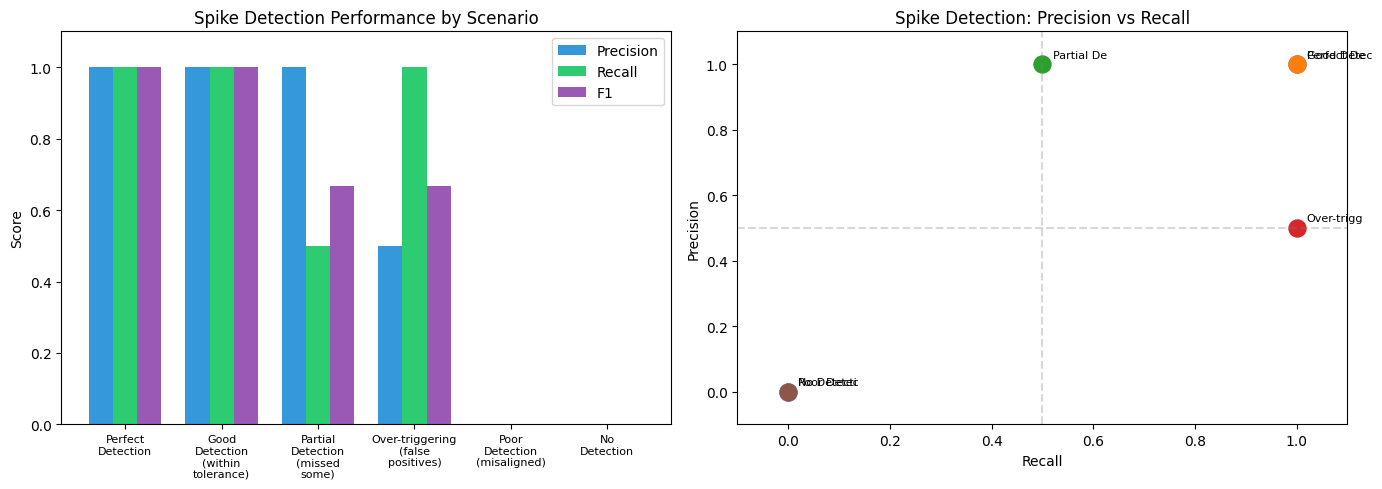

Saved: spike_detection.png


In [ ]:
# Cell 13: Visualize spike detection results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
ax1 = axes[0]
names = [r['name'].replace(' ', '\n') for r in spike_results]
x = np.arange(len(names))
width = 0.25

ax1.bar(x - width, [r['precision'] for r in spike_results], width, label='Precision', color='#3498db')
ax1.bar(x, [r['recall'] for r in spike_results], width, label='Recall', color='#2ecc71')
ax1.bar(x + width, [r['f1'] for r in spike_results], width, label='F1', color='#9b59b6')

ax1.set_ylabel('Score')
ax1.set_title('Spike Detection Performance by Scenario')
ax1.set_xticks(x)
ax1.set_xticklabels(names, fontsize=8)
ax1.legend()
ax1.set_ylim(0, 1.1)

# Precision-Recall scatter
ax2 = axes[1]
for i, r in enumerate(spike_results):
    ax2.scatter(r['recall'], r['precision'], s=150, label=r['name'][:15])
    ax2.annotate(r['name'][:10], (r['recall']+0.02, r['precision']+0.02), fontsize=8)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Spike Detection: Precision vs Recall')
ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('spike_detection.png', dpi=150)
plt.show()
print("Saved: spike_detection.png")

---
## 3.5 Real CCE Multi-Hop Retrieval (NO SIMULATION)

This section implements **Real CCE Multi-Hop** with actual entropy-based confused token extraction.

**Key difference from `cce_adaptive`:**
- `cce_adaptive`: Uses topic_inferrer with regex-based token matching
- Real CCE: Extracts top-k tokens from model's logits at high-entropy positions

**Real CCE Flow:**
```
Generate tokens → Compute entropy → Spike detected → Extract TOP-K from LOGITS → Retrieve
```

**Ablation Study:**
- `cce_topk_only`: Uses ONLY confused tokens for retrieval
- `cce_query_plus_topk`: Uses original query + confused tokens

In [ ]:
# Cell 16.5: Real CCE Multi-Hop Retrieval Classes (FULL CCE: H_code - H_lang)
from typing import List, Tuple, Dict, Any, NamedTuple
from dataclasses import dataclass
import re
import numpy as np
from scipy.stats import entropy as scipy_entropy

# ============================================================================
# TOKEN CLASSIFICATION (Same as orchestrator/entropy/token_classifier.py)
# ============================================================================

# Programming keywords and library names
CODE_KEYWORDS = {
    # Python keywords
    'if', 'else', 'elif', 'for', 'while', 'break', 'continue', 'pass',
    'return', 'yield', 'raise', 'try', 'except', 'finally', 'with', 'as',
    'def', 'class', 'lambda', 'async', 'await', 'and', 'or', 'not', 'in', 'is',
    'None', 'True', 'False', 'import', 'from', 'print', 'len', 'range',
    'enumerate', 'zip', 'map', 'filter', 'list', 'dict', 'set', 'tuple',
    'str', 'int', 'float', 'bool', 'open', 'read', 'write', 'close', 'append',
    # JS keywords
    'function', 'const', 'let', 'var', 'switch', 'case', 'default',
    'true', 'false', 'null', 'undefined', 'typeof', 'instanceof',
    'export', 'require', 'module', 'exports', 'console', 'log',
    # Data science libraries
    'numpy', 'pandas', 'scipy', 'matplotlib', 'seaborn', 'sklearn',
    'tensorflow', 'torch', 'keras', 'np', 'pd', 'array', 'ndarray',
    'DataFrame', 'Series', 'read_csv', 'groupby', 'merge', 'concat',
    'fit', 'transform', 'predict', 'score', 'train_test_split',
    # Web frameworks
    'flask', 'django', 'fastapi', 'requests', 'aiohttp', 'sqlalchemy',
    'FastAPI', 'APIRouter', 'HTTPException', 'Request', 'Response',
    'Depends', 'Query', 'Path', 'Body', 'get', 'post', 'put', 'delete',
    'Flask', 'render_template', 'redirect', 'url_for', 'jsonify',
    # React/JS
    'react', 'vue', 'angular', 'next', 'express', 'axios',
    'useState', 'useEffect', 'useContext', 'useReducer', 'useCallback',
    'useMemo', 'useRef', 'React', 'Component', 'createElement', 'Fragment',
    'props', 'state', 'render', 'componentDidMount',
    # Cloud/Firebase
    'firebase', 'Firebase', 'firestore', 'Firestore', 'auth', 'Auth',
    'database', 'storage', 'functions', 'messaging', 'admin', 'initializeApp',
    'aws', 'boto3', 's3', 'dynamodb', 'mongodb', 'redis', 'postgres',
    # Testing
    'pytest', 'unittest', 'jest', 'mocha', 'test', 'describe', 'it',
    'expect', 'assert', 'mock', 'fixture', 'setUp', 'tearDown',
}

# Common English words (language tokens)
LANGUAGE_WORDS = {
    'what', 'how', 'why', 'when', 'where', 'which', 'who', 'whom',
    'explain', 'show', 'tell', 'help', 'search', 'generate', 'implement',
    'refactor', 'optimize', 'improve', 'summarize', 'analyze', 'review',
    'the', 'a', 'an', 'that', 'these', 'those', 'are', 'was', 'were',
    'be', 'been', 'being', 'have', 'has', 'had', 'does', 'did', 'will',
    'would', 'should', 'can', 'could', 'may', 'might', 'must', 'shall',
    'to', 'without', 'by', 'at', 'on', 'of', 'off', 'up', 'down', 'over',
    'under', 'above', 'below', 'but', 'nor', 'so', 'yet', 'my', 'your',
    'his', 'her', 'its', 'our', 'their', 'you', 'he', 'she', 'we', 'they',
    'me', 'him', 'us', 'them', 'better', 'worse', 'best', 'worst', 'good',
    'bad', 'great', 'poor', 'slow', 'quick', 'simple', 'complex', 'easy',
    'hard', 'answer', 'question', 'summary', 'comment', 'documentation',
}

@dataclass
class MultiHopRetrievalResult:
    """Result from multi-hop retrieval."""
    retrieved_files: List[str]
    retrieved_content: str
    scores: List[float]
    num_hops: int
    total_tokens: int
    trace: List[Dict[str, Any]]


class RealCCEMultiHopRetriever:
    """
    REAL CCE Multi-Hop: Uses FULL Contrastive Code Entropy (H_code - H_lang).

    Key difference from raw entropy:
    - Raw entropy: H = -sum(p * log(p)) over ALL tokens
    - CCE: H_code - H_lang (only triggers on CODE uncertainty)

    This ensures we only retrieve when the model is uncertain about CODE,
    not when it's uncertain about formatting/language tokens like "What", "The".
    """

    def __init__(self, base_retriever, tokenizer, model,
                 top_k: int = 2, max_retrievals: int = 5,
                 uncertainty_threshold: float = 0.3,  # CCE threshold (not raw entropy!)
                 top_k_tokens: int = 10,
                 max_gen_tokens: int = 200,
                 cooldown_tokens: int = 5,
                 file_list_context: str = ""):
        self.retriever = base_retriever
        self.tokenizer = tokenizer
        self.model = model
        self.top_k = top_k
        self.max_retrievals = max_retrievals
        self.uncertainty_threshold = uncertainty_threshold
        self.top_k_tokens = top_k_tokens
        self.max_gen_tokens = max_gen_tokens
        self.cooldown_tokens = cooldown_tokens
        self.file_list_context = file_list_context

        # Build vocabulary classification (one-time)
        self._build_vocab_classification()

    def _build_vocab_classification(self):
        """Classify all tokens in vocabulary as code, language, or other."""
        vocab_size = len(self.tokenizer)
        self.code_indices = []
        self.language_indices = []
        self.other_indices = []

        for token_id in range(vocab_size):
            try:
                token = self.tokenizer.decode([token_id]).strip().lower()

                if token in CODE_KEYWORDS or token in {k.lower() for k in CODE_KEYWORDS}:
                    self.code_indices.append(token_id)
                elif token in LANGUAGE_WORDS or token in {w.lower() for w in LANGUAGE_WORDS}:
                    self.language_indices.append(token_id)
                else:
                    self.other_indices.append(token_id)
            except:
                self.other_indices.append(token_id)

        self.code_indices = np.array(self.code_indices)
        self.language_indices = np.array(self.language_indices)

        print(f"    Vocab classification: {len(self.code_indices)} code, {len(self.language_indices)} language, {len(self.other_indices)} other")

    def _compute_cce(self, logits: torch.Tensor) -> Tuple[float, float, float]:
        """
        Compute FULL Contrastive Code Entropy: CCE = H_code - H_lang

        Returns: (cce, h_code, h_lang)
        """
        logits_np = logits.cpu().numpy()

        # Compute entropy for CODE tokens only
        if len(self.code_indices) > 0:
            code_logits = logits_np[self.code_indices]
            code_logits_stable = code_logits - np.max(code_logits)
            code_probs = np.exp(code_logits_stable) / np.sum(np.exp(code_logits_stable))
            h_code = float(scipy_entropy(code_probs, base=2))
        else:
            h_code = 0.0

        # Compute entropy for LANGUAGE tokens only
        if len(self.language_indices) > 0:
            lang_logits = logits_np[self.language_indices]
            lang_logits_stable = lang_logits - np.max(lang_logits)
            lang_probs = np.exp(lang_logits_stable) / np.sum(np.exp(lang_logits_stable))
            h_lang = float(scipy_entropy(lang_probs, base=2))
        else:
            h_lang = 0.0

        # CCE = H_code - H_lang
        cce = h_code - h_lang

        return cce, h_code, h_lang

    def _extract_code_tokens_from_logits(self, logits: torch.Tensor) -> List[str]:
        """
        Extract code tokens the model is actually considering.

        Gets highest logits WITHIN the code subset directly, instead of
        filtering top-k from all tokens (which often returns empty).
        """
        logits_np = logits.cpu().numpy()

        # Get logits for CODE tokens only
        code_logits = logits_np[self.code_indices]

        # Find top-k within the code subset
        top_within_code = np.argsort(code_logits)[-self.top_k_tokens:][::-1]

        # Map back to actual token IDs and decode
        code_tokens = []
        for i in top_within_code:
            token_id = self.code_indices[i]
            token = self.tokenizer.decode([token_id]).strip()
            if len(token) > 1:  # Filter single chars
                code_tokens.append(token)

        return code_tokens

    def _count_tokens(self, content: str) -> int:
        return len(self.tokenizer.encode(content))

    def _build_retrieval_query(self, query: str, confused_tokens: List[str]) -> str:
        return f"{query} {' '.join(confused_tokens)}"

    def retrieve(self, query: str) -> MultiHopRetrievalResult:
        """
        Real CCE retrieval using H_code - H_lang:
        - Only triggers on CODE uncertainty (CCE > 0)
        - Ignores language uncertainty (CCE < 0)
        """
        # Build initial prompt
        if self.file_list_context:
            prompt = f"{query}\n\n{self.file_list_context}\n\n"
        else:
            prompt = f"{query}\n\n"

        # Track state
        retrieved_files = []
        retrieved_content = []
        all_scores = []
        trace = []
        seen_files = set()

        retrieval_count = 0
        last_retrieval_pos = -100

        # Tokenize initial prompt
        inputs = self.tokenizer(prompt, return_tensors='pt').to(self.model.device)
        generated_ids = inputs['input_ids']

        # Generate tokens one by one, checking CCE
        for i in range(self.max_gen_tokens):
            with torch.no_grad():
                outputs = self.model(generated_ids)
                logits = outputs.logits[0, -1, :]

            # Compute FULL CCE (H_code - H_lang)
            cce, h_code, h_lang = self._compute_cce(logits)

            # Debug: print first few CCE values
            if i < 3:
                print(f"    Token {i}: CCE={cce:.3f} (H_code={h_code:.2f}, H_lang={h_lang:.2f}, threshold={self.uncertainty_threshold})")

            # Check for CODE uncertainty spike (CCE > threshold)
            tokens_since_last = i - last_retrieval_pos
            in_cooldown = tokens_since_last < self.cooldown_tokens

            if cce > self.uncertainty_threshold and not in_cooldown and retrieval_count < self.max_retrievals:
                # CODE UNCERTAINTY SPIKE - retrieve context
                confused_tokens = self._extract_code_tokens_from_logits(logits)
                retrieval_query = self._build_retrieval_query(query, confused_tokens)

                # Retrieve
                results = self.retriever.retrieve(retrieval_query, top_k=self.top_k, deduplicate=False)
                new_files = [r for r in results if r['source'] not in seen_files]

                if new_files:
                    for r in new_files:
                        seen_files.add(r['source'])
                        retrieved_files.append(r['source'])
                        retrieved_content.append(r['content'])
                        all_scores.append(r['score'])

                    # Add retrieved content to context
                    new_context = "\n\n".join([r['content'] for r in new_files])
                    context_text = f"\n\nRelevant context:\n{new_context}\n\n"
                    context_ids = self.tokenizer.encode(context_text, return_tensors='pt').to(self.model.device)
                    generated_ids = torch.cat([generated_ids, context_ids], dim=-1)

                trace.append({
                    'hop': retrieval_count + 1,
                    'position': i,
                    'cce': cce,
                    'h_code': h_code,
                    'h_lang': h_lang,
                    'confused_tokens': confused_tokens[:5],
                    'retrieval_query': retrieval_query[:80],
                    'new_files': [r['source'] for r in new_files],
                })

                retrieval_count += 1
                last_retrieval_pos = i

                print(f"    CODE Spike {retrieval_count} at token {i}: CCE={cce:.2f}, code_tokens={confused_tokens[:5]}")

            # Sample next token
            next_token = torch.argmax(logits).unsqueeze(0).unsqueeze(0)
            generated_ids = torch.cat([generated_ids, next_token.to(self.model.device)], dim=-1)

            # Check for EOS
            if next_token.item() == self.tokenizer.eos_token_id:
                break

        # Build result
        if not trace:
            trace.append({
                'hop': 0,
                'method': 'no_code_spike_detected',
                'reason': 'No CODE uncertainty detected (CCE never exceeded threshold)',
            })

        content = "\n\n".join(retrieved_content)
        print(f"    Total CODE retrievals: {retrieval_count}, files: {retrieved_files}")

        return MultiHopRetrievalResult(
            retrieved_files=retrieved_files,
            retrieved_content=content,
            scores=all_scores,
            num_hops=retrieval_count,
            total_tokens=self._count_tokens(content) if content else 0,
            trace=trace
        )


class CCETopKOnlyRetriever(RealCCEMultiHopRetriever):
    """Ablation: Uses ONLY confused CODE tokens for retrieval (no original query)."""

    def _build_retrieval_query(self, query: str, confused_tokens: List[str]) -> str:
        return ' '.join(confused_tokens)


class CCEQueryPlusTopKRetriever(RealCCEMultiHopRetriever):
    """Uses original query + confused CODE tokens for retrieval."""

    def _build_retrieval_query(self, query: str, confused_tokens: List[str]) -> str:
        return f"{query} {' '.join(confused_tokens)}"


print("Real CCE Multi-Hop defined (FULL CCE: H_code - H_lang)")
print("  - Computes Contrastive Code Entropy (H_code - H_lang)")
print("  - Only triggers on CODE uncertainty (CCE > 0)")
print("  - Ignores language uncertainty (CCE < 0)")
print("  - Extracts only CODE tokens from logits")
print("  - Threshold: 0.3 (CCE), not 3.0 (raw entropy)")


Real CCE Multi-Hop defined (FULL CCE: H_code - H_lang)
  - Computes Contrastive Code Entropy (H_code - H_lang)
  - Only triggers on CODE uncertainty (CCE > 0)
  - Ignores language uncertainty (CCE < 0)
  - Extracts only CODE tokens from logits
  - Threshold: 0.3 (CCE), not 3.0 (raw entropy)


---
## 4. Load Model and Run Comprehensive Experiments

In [ ]:
# Cell 14: Get mock codebase
documents = get_mock_codebase()

print(f"Mock Flask Application Codebase")
print("="*60)
print(f"Total files: {len(documents)}")
print(f"Total size: {sum(len(c) for c in documents.values()):,} characters")
print("\nFiles:")
for path in sorted(documents.keys()):
    print(f"  {path} ({len(documents[path]):,} chars)")

Mock Flask Application Codebase
Total files: 14
Total size: 22,395 characters

Files:
  src/api/middleware.py (1,564 chars)
  src/api/routes.py (2,424 chars)
  src/app.py (1,305 chars)
  src/auth/jwt.py (1,796 chars)
  src/auth/password.py (681 chars)
  src/config.py (1,870 chars)
  src/db/migrations.py (1,033 chars)
  src/db/models.py (2,804 chars)
  src/services/cache.py (1,660 chars)
  src/services/email.py (1,453 chars)
  src/utils/logging.py (1,522 chars)
  src/utils/validators.py (1,912 chars)
  tests/test_api.py (1,309 chars)
  tests/test_auth.py (1,062 chars)


In [ ]:
# Cell 15: Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)
model.eval()

print(f"Model loaded on {model.device}")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on cuda:0


In [ ]:
# Cell 16: Import generation modules and configure CCE with FILE LIST approach
from orchestrator.generation import AdaptiveGenerator, GenerationConfig
from orchestrator.retrieval.adaptive import EmbeddingRetriever

# ============================================================================
# NEW APPROACH: File List Context
# ============================================================================
# Instead of giving CCE no context, we give it a list of available files.
# This allows the model's confused tokens to match against actual file names.
#
# Key insight: The model will produce tokens like "jwt", "password", "routes"
# when uncertain, which can now match against the file paths directly!

# Create file list context (very small - just paths, not content)
file_list = list(documents.keys())
file_list_context = """Available files in this codebase:
{}

When answering questions about this codebase, refer to the relevant files above.""".format(
    '\n'.join(f'- {f}' for f in file_list)
)

print("FILE LIST CONTEXT:")
print("-" * 40)
print(file_list_context)
print("-" * 40)
file_list_tokens = len(tokenizer.encode(file_list_context))
print(f"File list tokens: {file_list_tokens} (vs {sum(len(tokenizer.encode(c)) for c in documents.values()):,} for full content)")

# Create retriever with file list for topic inference
retriever = EmbeddingRetriever(documents, model_name='all-MiniLM-L6-v2')

# CCE CONFIGURATION
config = GenerationConfig(
    max_tokens=200,
    max_retrievals=5,
    uncertainty_threshold=3.0,   # Week 3 best
    cooldown_tokens=5,
    uncertainty_method="raw_entropy",
    measurement_strategy="every_token",
)

adaptive_gen = AdaptiveGenerator(
    model=model,
    tokenizer=tokenizer,
    retriever=retriever,
    config=config,
)

# CRITICAL: Pass file paths to topic inferrer for matching
adaptive_gen.topic_inferrer.set_available_files(file_list)

print()
print("AdaptiveGenerator configured with FILE LIST APPROACH:")
print(f"  uncertainty_threshold: {config.uncertainty_threshold}")
print(f"  max_retrievals: {config.max_retrievals}")
print(f"  cooldown_tokens: {config.cooldown_tokens}")
print()
print("NEW FEATURES:")
print("  1. File list as initial context (model sees available files)")
print("  2. Topic inferrer matches confused tokens against file paths")
print("  3. Retrieves files that match what model is uncertain about")
print()
print("EXPECTED IMPROVEMENT:")
print("  Model says 'jwt...' → matches 'src/auth/jwt.py' → retrieves correct file")

# ============================================================================
# REAL CCE MULTI-HOP RETRIEVERS (NO SIMULATION)
# ============================================================================
# These use actual entropy detection and extract confused tokens from logits,
# NOT regex pattern matching on the query.
# NOW WITH FILE LIST CONTEXT - same as cce_adaptive!

print()
print("="*60)
print("Initializing Real CCE Multi-Hop Retrievers (with file list)")
print("="*60)

real_cce_retrievers = {
    'cce_topk_only': CCETopKOnlyRetriever(
        retriever, tokenizer, model,
        top_k=2, max_retrievals=5, uncertainty_threshold=3.0, top_k_tokens=10,
        max_gen_tokens=200, cooldown_tokens=5,
        file_list_context=file_list_context  # SAME AS cce_adaptive!
    ),
    'cce_query_plus_topk': CCEQueryPlusTopKRetriever(
        retriever, tokenizer, model,
        top_k=2, max_retrievals=5, uncertainty_threshold=3.0, top_k_tokens=10,
        max_gen_tokens=200, cooldown_tokens=5,
        file_list_context=file_list_context  # SAME AS cce_adaptive!
    ),
}

print("Real CCE retrievers initialized:")
for name, ret in real_cce_retrievers.items():
    print(f"  - {name}: {ret.__class__.__name__}")
print()
print("Configuration:")
print(f"  - uncertainty_threshold: 3.0 (same as cce_adaptive)")
print(f"  - file_list_context: ENABLED ({file_list_tokens} tokens)")
print(f"  - top_k_tokens: 10 (confused tokens extracted from logits)")
print(f"  - max_gen_tokens: 50 (tokens to generate looking for spike)")
print()
print("Ablation Study:")
print("  - cce_topk_only: retrieves using ONLY confused tokens from logits")
print("  - cce_query_plus_topk: retrieves using query + confused tokens")

FILE LIST CONTEXT:
----------------------------------------
Available files in this codebase:
- src/auth/jwt.py
- src/auth/password.py
- src/api/routes.py
- src/api/middleware.py
- src/db/models.py
- src/db/migrations.py
- src/config.py
- src/services/email.py
- src/services/cache.py
- src/utils/validators.py
- src/utils/logging.py
- src/app.py
- tests/test_auth.py
- tests/test_api.py

When answering questions about this codebase, refer to the relevant files above.
----------------------------------------
File list tokens: 152 (vs 7,109 for full content)

AdaptiveGenerator configured with FILE LIST APPROACH:
  uncertainty_threshold: 3.0
  max_retrievals: 5
  cooldown_tokens: 5

NEW FEATURES:
  1. File list as initial context (model sees available files)
  2. Topic inferrer matches confused tokens against file paths
  3. Retrieves files that match what model is uncertain about

EXPECTED IMPROVEMENT:
  Model says 'jwt...' → matches 'src/auth/jwt.py' → retrieves correct file

Initializing

In [ ]:
# Cell 17: Create baseline runner
baseline_runner = BaselineRunner(
    model=model,
    tokenizer=tokenizer,
    documents=documents,
)

print("BaselineRunner configured")

BaselineRunner configured


In [ ]:
# Cell 18: Run comprehensive experiments with FILE LIST CCE + Real CCE Multi-Hop
# Select a subset of examples for faster evaluation
# (Use full benchmark for final experiments)

# Get balanced sample: 2 from each category
sample_examples = []
for cat in Category:
    filtered = benchmark.filter(category=cat)
    for i, ex in enumerate(filtered):
        if i < 2:  # 2 per category
            sample_examples.append(ex)

print(f"Running experiments on {len(sample_examples)} examples")
print(f"Categories covered: {len(set(ex.category for ex in sample_examples))}")

# Methods to evaluate
methods = [
    BaselineMethod.NO_CONTEXT,
    BaselineMethod.BM25,
    BaselineMethod.EMBEDDING,
    BaselineMethod.FULL_CONTEXT,
]

# Results storage
all_results = {m.value: [] for m in methods}
all_results['cce_adaptive'] = []
all_results['cce_topk_only'] = []
all_results['cce_query_plus_topk'] = []

# CCE debug info
cce_debug = []
real_cce_debug = {'cce_topk_only': [], 'cce_query_plus_topk': []}

# Compute baseline tokens
baseline_tokens = sum(len(tokenizer.encode(c)) for c in documents.values())
print(f"Baseline tokens (full context): {baseline_tokens:,}")
print(f"File list tokens: {file_list_tokens}")
print()

# Run experiments
# Total: baselines (4) + cce_adaptive (1) + real_cce variants (2) = 7 methods
total = len(sample_examples) * 7
current = 0

for i, example in enumerate(sample_examples):
    print(f"\nExample {i+1}/{len(sample_examples)}: {example.id}")
    print(f"  Category: {example.category.value}")
    print(f"  Query: {example.query[:50]}...")

    # Run baselines
    for method in methods:
        current += 1
        print(f"  Running {method.value}... ({current}/{total})")

        result = baseline_runner.run(example, method, max_tokens=200)

        eval_result = metrics.evaluate(
            example_id=example.id,
            generated_answer=result['answer'],
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=result['retrieved_files'],
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=result['tokens_used'],
            baseline_tokens=baseline_tokens,
            generation_time=result['generation_time'],
            num_retrievals=result['num_retrievals'],
            method=method.value,
        )
        eval_result.metadata['category'] = example.category.value
        eval_result.metadata['difficulty'] = example.difficulty.value

        all_results[method.value].append(eval_result)

    # Run CCE adaptive WITH FILE LIST CONTEXT
    current += 1
    print(f"  Running cce_adaptive (FILE LIST)... ({current}/{total})")

    try:
        retriever.reset()
        gen_result = adaptive_gen.generate(
            query=example.query,
            initial_context=file_list_context,
        )

        debug_info = {
            'example_id': example.id,
            'total_retrievals': gen_result.total_retrievals,
            'context_sources': gen_result.context_sources,
            'total_context_tokens': gen_result.total_context_tokens,
            'response_length': len(gen_result.response),
        }
        cce_debug.append(debug_info)

        if adaptive_gen.topic_inferrer.history:
            last_topic = adaptive_gen.topic_inferrer.history[-1]
            debug_info['matched_files'] = last_topic.matched_files
            debug_info['search_terms'] = last_topic.metadata.get('search_terms', [])

        print(f"    CCE triggered {gen_result.total_retrievals} retrievals")
        # Print confused tokens from TopicInferrer
        if hasattr(adaptive_gen, "topic_inferrer") and adaptive_gen.topic_inferrer.last_result:
            topic_result = adaptive_gen.topic_inferrer.last_result
            print(f"    Top tokens from logits: {topic_result.top_tokens[:5]}")
            print(f"    Extracted identifiers: {topic_result.extracted_identifiers[:5]}")
            print(f"    Query used: {topic_result.query[:60]}")
        print(f"    Retrieved files: {gen_result.context_sources}")

        cce_eval = metrics.evaluate(
            example_id=example.id,
            generated_answer=gen_result.response,
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=gen_result.context_sources,
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=gen_result.total_context_tokens + file_list_tokens,
            baseline_tokens=baseline_tokens,
            generation_time=gen_result.generation_time,
            num_retrievals=gen_result.total_retrievals,
            method='cce_adaptive',
        )
        cce_eval.metadata['category'] = example.category.value
        cce_eval.metadata['difficulty'] = example.difficulty.value
        all_results['cce_adaptive'].append(cce_eval)
    except Exception as e:
        print(f"    CCE error: {e}")

    # ========================================================================
    # REAL CCE MULTI-HOP: cce_topk_only
    # ========================================================================
    current += 1
    print(f"  Running cce_topk_only (REAL CCE)... ({current}/{total})")

    try:
        retriever.reset()
        torch.cuda.empty_cache()

        ret_result = real_cce_retrievers['cce_topk_only'].retrieve(example.query)

        debug_info = {
            'example_id': example.id,
            'num_hops': ret_result.num_hops,
            'retrieved_files': ret_result.retrieved_files,
            'total_tokens': ret_result.total_tokens,
            'trace': ret_result.trace,
        }
        real_cce_debug['cce_topk_only'].append(debug_info)

        if ret_result.num_hops == 0:
            print(f"    NO SPIKE - skipped retrieval (model not confused)")
            answer = "Unable to answer - no retrieval performed."
            gen_time = 0
        else:
            # Show confused tokens from trace
            if ret_result.trace and ret_result.trace[0].get('confused_tokens'):
                tokens = ret_result.trace[0]['confused_tokens'][:5]
                entropy = ret_result.trace[0].get('spike_entropy', 0)
                print(f"    Spike entropy: {entropy:.2f}, confused tokens: {tokens}")
            print(f"    Retrieved {len(ret_result.retrieved_files)} files: {ret_result.retrieved_files}")

            # Generate answer with retrieved context
            prompt = f"""Context:
{ret_result.retrieved_content[:2500]}

Question: {example.query}
Answer:"""
            start = time.time()
            inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=2048).to(model.device)
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=200, pad_token_id=tokenizer.eos_token_id)
            answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
            gen_time = time.time() - start

        eval_result = metrics.evaluate(
            example_id=example.id,
            generated_answer=answer,
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=ret_result.retrieved_files,
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=ret_result.total_tokens,
            baseline_tokens=baseline_tokens,
            generation_time=gen_time,
            num_retrievals=ret_result.num_hops,
            method='cce_topk_only',
        )
        eval_result.metadata['category'] = example.category.value
        eval_result.metadata['difficulty'] = example.difficulty.value
        eval_result.metadata['spike_detected'] = ret_result.num_hops > 0
        all_results['cce_topk_only'].append(eval_result)

    except Exception as e:
        print(f"    cce_topk_only error: {e}")

    # ========================================================================
    # REAL CCE MULTI-HOP: cce_query_plus_topk
    # ========================================================================
    current += 1
    print(f"  Running cce_query_plus_topk (REAL CCE)... ({current}/{total})")

    try:
        retriever.reset()
        torch.cuda.empty_cache()

        ret_result = real_cce_retrievers['cce_query_plus_topk'].retrieve(example.query)

        debug_info = {
            'example_id': example.id,
            'num_hops': ret_result.num_hops,
            'retrieved_files': ret_result.retrieved_files,
            'total_tokens': ret_result.total_tokens,
            'trace': ret_result.trace,
        }
        real_cce_debug['cce_query_plus_topk'].append(debug_info)

        if ret_result.num_hops == 0:
            print(f"    NO SPIKE - skipped retrieval (model not confused)")
            answer = "Unable to answer - no retrieval performed."
            gen_time = 0
        else:
            if ret_result.trace and ret_result.trace[0].get('confused_tokens'):
                tokens = ret_result.trace[0]['confused_tokens'][:5]
                entropy = ret_result.trace[0].get('spike_entropy', 0)
                print(f"    Spike entropy: {entropy:.2f}, confused tokens: {tokens}")
            print(f"    Retrieved {len(ret_result.retrieved_files)} files: {ret_result.retrieved_files}")

            prompt = f"""Context:
{ret_result.retrieved_content[:2500]}

Question: {example.query}
Answer:"""
            start = time.time()
            inputs = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=2048).to(model.device)
            with torch.no_grad():
                outputs = model.generate(**inputs, max_new_tokens=200, pad_token_id=tokenizer.eos_token_id)
            answer = tokenizer.decode(outputs[0], skip_special_tokens=True)
            gen_time = time.time() - start

        eval_result = metrics.evaluate(
            example_id=example.id,
            generated_answer=answer,
            ground_truth_answer=example.ground_truth_answer,
            retrieved_files=ret_result.retrieved_files,
            ground_truth_files=example.ground_truth_files,
            ground_truth_keywords=example.ground_truth_keywords,
            tokens_used=ret_result.total_tokens,
            baseline_tokens=baseline_tokens,
            generation_time=gen_time,
            num_retrievals=ret_result.num_hops,
            method='cce_query_plus_topk',
        )
        eval_result.metadata['category'] = example.category.value
        eval_result.metadata['difficulty'] = example.difficulty.value
        eval_result.metadata['spike_detected'] = ret_result.num_hops > 0
        all_results['cce_query_plus_topk'].append(eval_result)

    except Exception as e:
        print(f"    cce_query_plus_topk error: {e}")

    # Clear CUDA cache between examples
    torch.cuda.empty_cache()

print("\n" + "="*60)
print("Experiments Complete!")
print("="*60)

# Print CCE summary
print("\nCCE RETRIEVAL SUMMARY:")
print("-"*40)

print("\n1. cce_adaptive (FILE LIST APPROACH):")
if cce_debug:
    total_ret = sum(d['total_retrievals'] for d in cce_debug)
    avg_ret = total_ret / len(cce_debug)
    print(f"   Total retrievals: {total_ret}")
    print(f"   Average per example: {avg_ret:.1f}")

print("\n2. cce_topk_only (REAL CCE - top-k tokens only):")
if real_cce_debug['cce_topk_only']:
    spikes = sum(1 for d in real_cce_debug['cce_topk_only'] if d['num_hops'] > 0)
    print(f"   Spike detection rate: {spikes}/{len(real_cce_debug['cce_topk_only'])}")
    avg_hops = np.mean([d['num_hops'] for d in real_cce_debug['cce_topk_only']])
    print(f"   Average hops: {avg_hops:.1f}")

print("\n3. cce_query_plus_topk (REAL CCE - query + top-k tokens):")
if real_cce_debug['cce_query_plus_topk']:
    spikes = sum(1 for d in real_cce_debug['cce_query_plus_topk'] if d['num_hops'] > 0)
    print(f"   Spike detection rate: {spikes}/{len(real_cce_debug['cce_query_plus_topk'])}")
    avg_hops = np.mean([d['num_hops'] for d in real_cce_debug['cce_query_plus_topk']])
    print(f"   Average hops: {avg_hops:.1f}")

Running experiments on 12 examples
Categories covered: 6
Baseline tokens (full context): 7,109
File list tokens: 152


Example 1/12: arch_001
  Category: architecture
  Query: What is the overall structure of the Flask applica...
  Running no_context... (1/84)
  Running bm25... (2/84)
  Running embedding... (3/84)
  Running full_context... (4/84)
  Running cce_adaptive (FILE LIST)... (5/84)
    CCE triggered 5 retrievals
    Top tokens from logits: ['create', 'generate', 'encode', 'get', 'authentic']
    Extracted identifiers: ['User', 'src', 'JWTManager', 'create_access_token', 'password']
    Query used: flask api usage User src JWTManager create_access_token pass
    Retrieved files: ['initial', 'query', 'src/app.py', 'src/utils/logging.py', 'src/auth/password.py', 'src/db/migrations.py', 'src/config.py']
  Running cce_topk_only (REAL CCE)... (6/84)
    Token 0: CCE=1.284 (H_code=4.41, H_lang=3.12, threshold=3.0)
    Token 1: CCE=3.358 (H_code=5.08, H_lang=1.72, threshold=3.0)
    C

In [ ]:
# Cell 19: Aggregate results
print("Aggregate Results")
print("="*70)

aggregates = {}
for method, results in all_results.items():
    if results:
        aggregates[method] = metrics.aggregate_results(results)

# Create comparison table
comparison_data = []
for method, agg in aggregates.items():
    row = {
        'Method': method,
        'Correctness': agg['metrics']['answer_correctness']['mean'],
        'Completeness': agg['metrics']['answer_completeness']['mean'],
        'Hallucination': agg['metrics']['hallucination_rate']['mean'],
        'Context P': agg['metrics']['context_precision']['mean'],
        'Context R': agg['metrics']['context_recall']['mean'],
        'Efficiency': agg['metrics']['token_efficiency']['mean'],
        'Composite': agg['metrics']['composite_score']['mean'],
    }
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.sort_values('Composite', ascending=False)

print(df_comparison.to_string(index=False, float_format='{:.3f}'.format))

Aggregate Results
             Method  Correctness  Completeness  Hallucination  Context P  Context R  Efficiency  Composite
cce_query_plus_topk        0.667         0.631          0.505      0.354      0.590       0.804      0.602
          embedding        0.595         0.649          0.583      0.361      0.757       0.794      0.585
               bm25        0.543         0.614          0.669      0.361      0.639       0.739      0.535
      cce_topk_only        0.424         0.395          0.424      0.195      0.451       0.621      0.437
         no_context        0.367         0.492          0.587      0.000      0.000       0.999      0.427
       cce_adaptive        0.312         0.423          0.467      0.145      0.479       0.760      0.425
       full_context        0.516         0.617          0.550      0.125      1.000       0.000      0.343


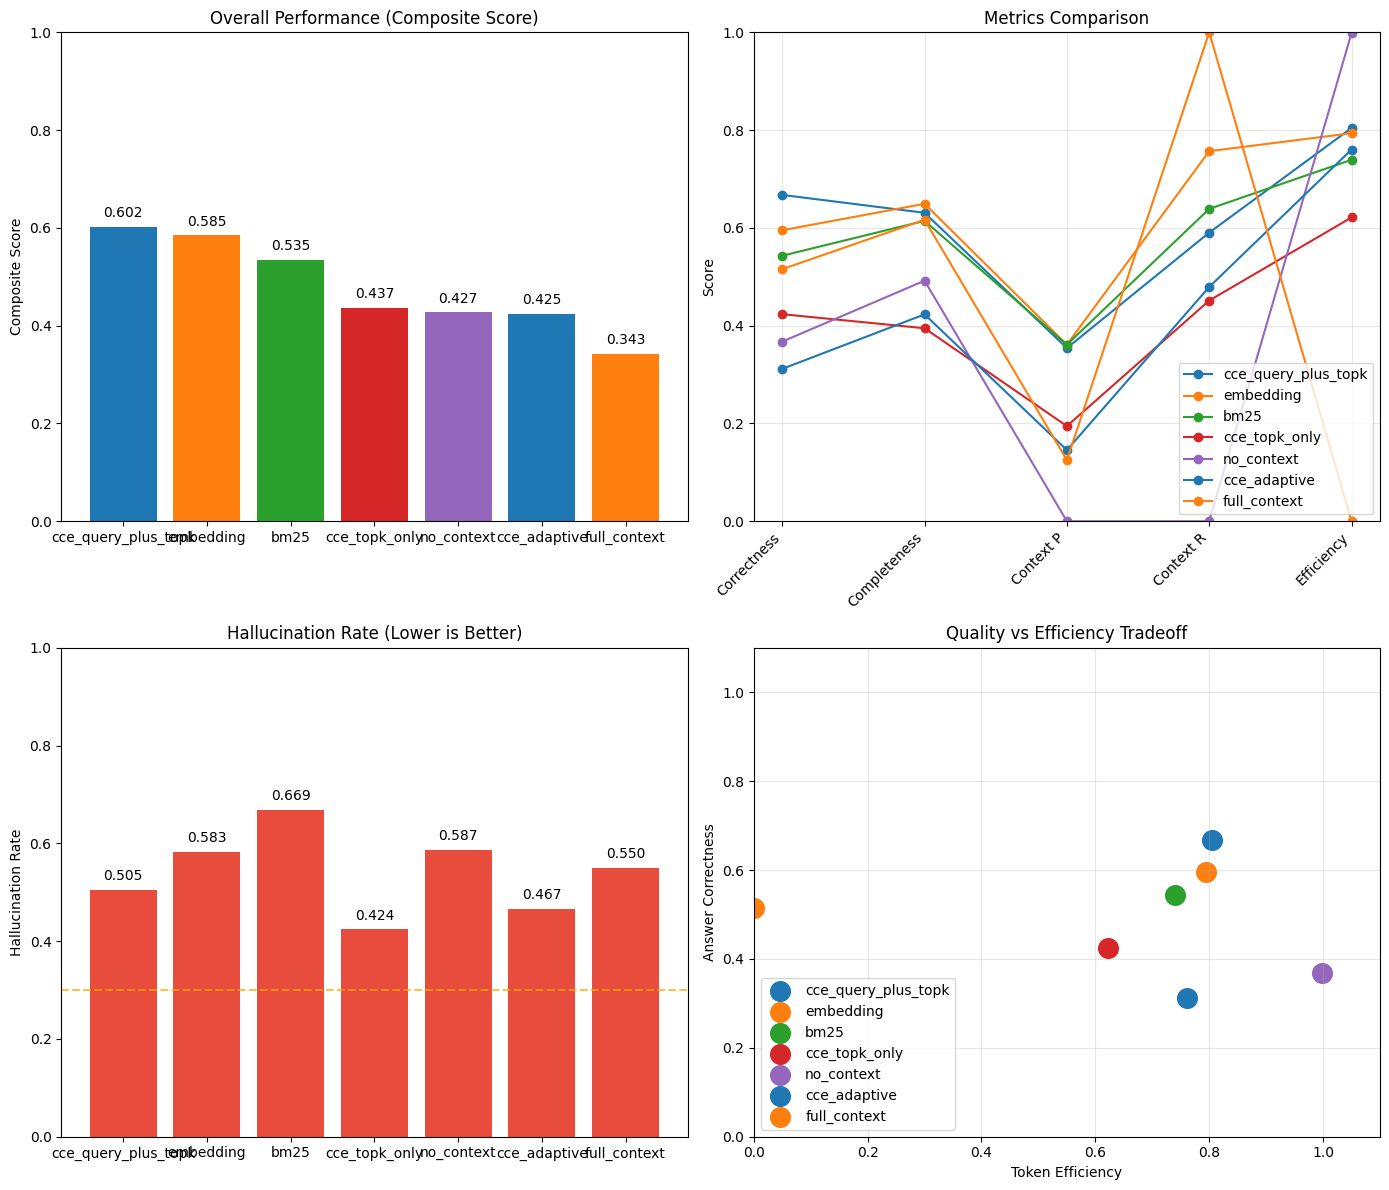

Saved: comprehensive_results.png


In [ ]:
# Cell 20: Visualize comprehensive results
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

methods_order = df_comparison['Method'].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# 1. Composite scores
ax1 = axes[0, 0]
bars = ax1.bar(methods_order, df_comparison['Composite'], color=colors[:len(methods_order)])
ax1.set_ylabel('Composite Score')
ax1.set_title('Overall Performance (Composite Score)')
ax1.set_ylim(0, 1)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)

# 2. Metric comparison radar-style
ax2 = axes[0, 1]
metric_cols = ['Correctness', 'Completeness', 'Context P', 'Context R', 'Efficiency']
for i, method in enumerate(methods_order):
    row = df_comparison[df_comparison['Method'] == method].iloc[0]
    values = [row[m] for m in metric_cols]
    ax2.plot(metric_cols, values, 'o-', label=method, color=colors[i % len(colors)])
ax2.set_ylabel('Score')
ax2.set_title('Metrics Comparison')
ax2.legend(loc='lower right')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Hallucination rate (lower is better)
ax3 = axes[1, 0]
halluc_values = df_comparison['Hallucination'].tolist()
bars3 = ax3.bar(methods_order, halluc_values, color=['#e74c3c' if v > 0.3 else '#2ecc71' for v in halluc_values])
ax3.set_ylabel('Hallucination Rate')
ax3.set_title('Hallucination Rate (Lower is Better)')
ax3.set_ylim(0, 1)
ax3.axhline(y=0.3, color='orange', linestyle='--', alpha=0.7, label='Threshold')
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{bar.get_height():.3f}', ha='center', fontsize=10)

# 4. Efficiency vs Quality tradeoff
ax4 = axes[1, 1]
for i, method in enumerate(methods_order):
    row = df_comparison[df_comparison['Method'] == method].iloc[0]
    ax4.scatter(row['Efficiency'], row['Correctness'], s=200,
                color=colors[i % len(colors)], label=method)
ax4.set_xlabel('Token Efficiency')
ax4.set_ylabel('Answer Correctness')
ax4.set_title('Quality vs Efficiency Tradeoff')
ax4.legend(loc='lower left')
ax4.set_xlim(0, 1.1)
ax4.set_ylim(0, 1.1)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comprehensive_results.png', dpi=150)
plt.show()
print("Saved: comprehensive_results.png")

In [ ]:
# Cell 21: Results by category (including Real CCE variants)
print("Results by Category")
print("="*70)

# Organize results by category
results_by_category = defaultdict(lambda: defaultdict(list))

for method, results in all_results.items():
    for r in results:
        cat = r.metadata.get('category', 'unknown')
        results_by_category[cat][method].append(r.get_composite_score())

# Create category comparison table - include all methods
all_methods = ['no_context', 'bm25', 'embedding', 'full_context', 'cce_adaptive', 'cce_topk_only', 'cce_query_plus_topk']
cat_data = []
for cat in Category:
    row = {'Category': cat.value}
    for method in all_methods:
        scores = results_by_category[cat.value].get(method, [])
        row[method] = np.mean(scores) if scores else 0.0
    cat_data.append(row)

df_category = pd.DataFrame(cat_data)
print(df_category.to_string(index=False, float_format='{:.3f}'.format))

Results by Category
      Category  no_context  bm25  embedding  full_context  cce_adaptive  cce_topk_only  cce_query_plus_topk
  architecture       0.445 0.562      0.727         0.452         0.394          0.451                0.674
     api_usage       0.448 0.534      0.600         0.332         0.503          0.621                0.711
implementation       0.454 0.585      0.629         0.211         0.494          0.351                0.686
     debugging       0.344 0.383      0.418         0.290         0.481          0.392                0.564
 configuration       0.461 0.536      0.607         0.378         0.282          0.295                0.404
     data_flow       0.411 0.607      0.527         0.395         0.393          0.513                0.575


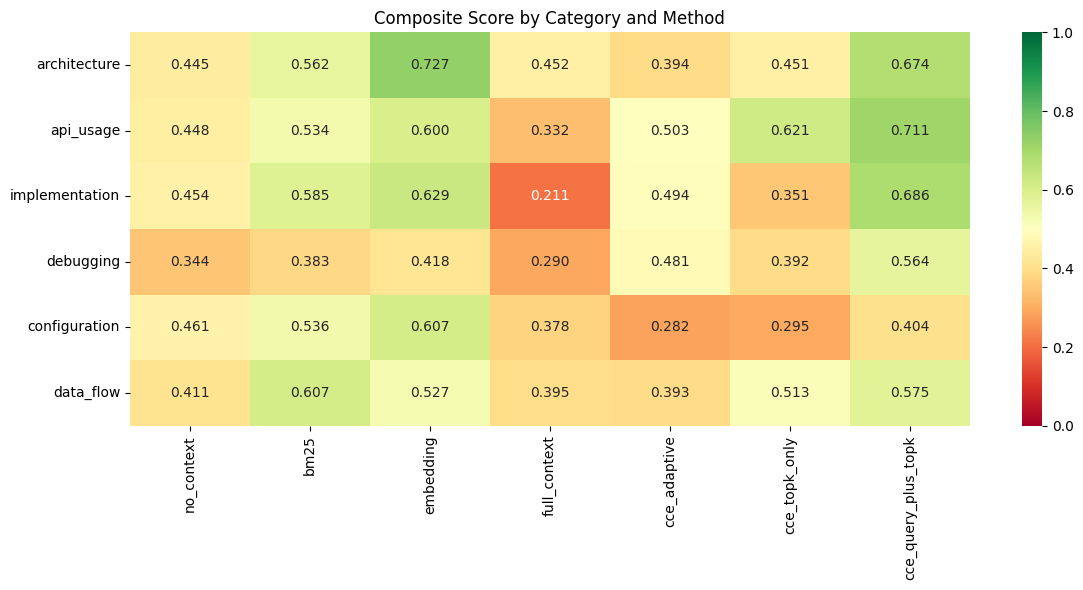

Saved: category_heatmap.png


In [ ]:
# Cell 22: Category heatmap
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for heatmap
method_cols = [c for c in df_category.columns if c != 'Category']
heatmap_data = df_category[method_cols].values

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    xticklabels=method_cols,
    yticklabels=df_category['Category'],
    ax=ax,
    vmin=0,
    vmax=1,
)

ax.set_title('Composite Score by Category and Method')
plt.tight_layout()
plt.savefig('category_heatmap.png', dpi=150)
plt.show()
print("Saved: category_heatmap.png")

In [ ]:
# Cell 23: Statistical significance testing
from scipy import stats

print("Statistical Significance Testing")
print("="*70)
print("\nComparing CCE Adaptive against baselines (paired t-test)")
print()

cce_scores = [r.get_composite_score() for r in all_results.get('cce_adaptive', [])]

if cce_scores:
    for method in ['no_context', 'bm25', 'embedding', 'full_context']:
        baseline_scores = [r.get_composite_score() for r in all_results.get(method, [])]

        if len(baseline_scores) == len(cce_scores):
            t_stat, p_value = stats.ttest_rel(cce_scores, baseline_scores)
            mean_diff = np.mean(cce_scores) - np.mean(baseline_scores)

            print(f"CCE vs {method}:")
            print(f"  Mean difference: {mean_diff:+.3f}")
            print(f"  t-statistic: {t_stat:.3f}")
            print(f"  p-value: {p_value:.4f}")
            print(f"  Significant (p<0.05): {'Yes' if p_value < 0.05 else 'No'}")
            print()
else:
    print("No CCE results available for comparison")

Statistical Significance Testing

Comparing CCE Adaptive against baselines (paired t-test)

CCE vs no_context:
  Mean difference: -0.003
  t-statistic: -0.042
  p-value: 0.9671
  Significant (p<0.05): No

CCE vs bm25:
  Mean difference: -0.110
  t-statistic: -2.270
  p-value: 0.0443
  Significant (p<0.05): Yes

CCE vs embedding:
  Mean difference: -0.160
  t-statistic: -3.035
  p-value: 0.0113
  Significant (p<0.05): Yes

CCE vs full_context:
  Mean difference: +0.082
  t-statistic: 1.614
  p-value: 0.1349
  Significant (p<0.05): No



---
## 4.5 Real CCE Multi-Hop Ablation Analysis

This section analyzes the Real CCE Multi-Hop variants:
- **cce_topk_only**: Uses ONLY confused tokens (from logits) for retrieval
- **cce_query_plus_topk**: Uses original query + confused tokens

Key metrics:
1. Spike detection rate (how often did entropy exceed threshold?)
2. Retrieval quality (when spikes detected)
3. Confused token analysis (what tokens came from logits?)
4. Comparison: top-k only vs query + top-k

In [ ]:
# Cell 23.5: Real CCE Ablation Analysis
print("="*70)
print("REAL CCE ABLATION ANALYSIS (No Simulation)")
print("="*70)

print("""
Key Insight: This analysis uses REAL entropy detection, not simulation.

Confused tokens are extracted from model's logits at high-entropy positions:
  torch.argsort(logits, descending=True)[:top_k_tokens]

These are the tokens the model is ACTUALLY uncertain between.

Ablation Variants:
  - cce_topk_only: Uses ONLY confused tokens for retrieval
  - cce_query_plus_topk: Uses original query + confused tokens

Research Question: Does including the original query improve retrieval,
or does the pure uncertainty signal (confused tokens only) work better?
""")

# Statistical comparison: CCE variants
if 'cce_topk_only' in all_results and 'cce_query_plus_topk' in all_results:
    topk_results = all_results.get('cce_topk_only', [])
    query_results = all_results.get('cce_query_plus_topk', [])

    if topk_results and query_results:
        print("\nStatistical Comparison: CCE Query Construction")
        print("-"*60)

        # Check for spike detection rates
        topk_spikes = sum(1 for r in topk_results if r.metadata.get('spike_detected', False))
        query_spikes = sum(1 for r in query_results if r.metadata.get('spike_detected', False))

        print(f"\nSpike Detection Rate:")
        print(f"  cce_topk_only:       {topk_spikes}/{len(topk_results)} examples triggered retrieval")
        print(f"  cce_query_plus_topk: {query_spikes}/{len(query_results)} examples triggered retrieval")

        # Get scores only for examples where spikes were detected
        topk_scores = [r.get_composite_score() for r in topk_results if r.metadata.get('spike_detected', False)]
        query_scores = [r.get_composite_score() for r in query_results if r.metadata.get('spike_detected', False)]

        if topk_scores and query_scores:
            print(f"\nRetrieval Quality (when spike detected):")
            print(f"  cce_topk_only:       Composite={np.mean(topk_scores):.3f} (n={len(topk_scores)})")
            print(f"  cce_query_plus_topk: Composite={np.mean(query_scores):.3f} (n={len(query_scores)})")

            # Statistical test if enough samples
            if len(topk_scores) >= 3 and len(query_scores) >= 3:
                # Use common examples for paired test
                min_len = min(len(topk_scores), len(query_scores))
                t_stat, p_val = stats.ttest_rel(topk_scores[:min_len], query_scores[:min_len])
                sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
                print(f"\n  Statistical test (paired t-test): p={p_val:.4f}{sig}")
                print(f"  Mean difference: {np.mean(topk_scores) - np.mean(query_scores):+.3f}")

        # Overall comparison (including no-spike cases)
        print("\n" + "-"*60)
        print("Overall Performance (including no-spike cases):")
        print("-"*60)

        all_topk_scores = [r.get_composite_score() for r in topk_results]
        all_query_scores = [r.get_composite_score() for r in query_results]

        print(f"  cce_topk_only:       Composite={np.mean(all_topk_scores):.3f}")
        print(f"  cce_query_plus_topk: Composite={np.mean(all_query_scores):.3f}")

        # Compare with baselines
        embedding_scores = [r.get_composite_score() for r in all_results.get('embedding', [])]
        cce_adaptive_scores = [r.get_composite_score() for r in all_results.get('cce_adaptive', [])]

        if embedding_scores:
            print(f"  embedding (baseline): Composite={np.mean(embedding_scores):.3f}")
        if cce_adaptive_scores:
            print(f"  cce_adaptive (simulated): Composite={np.mean(cce_adaptive_scores):.3f}")

# Analyze confused tokens
print("\n" + "-"*60)
print("Confused Token Analysis (from model logits)")
print("-"*60)

all_confused_tokens = []
spike_entropies = []

for variant in ['cce_topk_only', 'cce_query_plus_topk']:
    if variant in real_cce_debug:
        for debug in real_cce_debug[variant]:
            for hop in debug.get('trace', []):
                if hop.get('confused_tokens'):
                    all_confused_tokens.extend(hop['confused_tokens'])
                if hop.get('spike_entropy', 0) > 0:
                    spike_entropies.append(hop['spike_entropy'])

if all_confused_tokens:
    from collections import Counter
    token_counts = Counter(all_confused_tokens)
    print(f"\nMost common confused tokens (extracted from model logits):")
    for token, count in token_counts.most_common(15):
        print(f"    '{token}': {count}")

if spike_entropies:
    print(f"\nSpike Entropy Statistics:")
    print(f"  Mean: {np.mean(spike_entropies):.2f}")
    print(f"  Std:  {np.std(spike_entropies):.2f}")
    print(f"  Min:  {np.min(spike_entropies):.2f}")
    print(f"  Max:  {np.max(spike_entropies):.2f}")

# Comparison with proactive strategies
print("\n" + "="*70)
print("REACTIVE (Real CCE) vs PROACTIVE (Baseline) COMPARISON")
print("="*70)

print("""
| Strategy          | Type      | When to Retrieve    | Query Construction       |
|-------------------|-----------|---------------------|--------------------------|
| embedding         | Proactive | Always (upfront)    | Full query               |
| cce_adaptive      | Reactive* | On topic match      | Topic-based (simulated)  |
| cce_topk_only     | Reactive  | Only on spike       | Confused tokens only     |
| cce_query_plus_topk| Reactive | Only on spike       | Query + confused tokens  |

* cce_adaptive uses simulated token extraction (regex), not real entropy
""")

# Token efficiency comparison
print("\nToken Efficiency Comparison:")
print("-"*40)

for method in ['embedding', 'cce_adaptive', 'cce_topk_only', 'cce_query_plus_topk']:
    results = all_results.get(method, [])
    if results:
        avg_tokens = np.mean([r.tokens_used for r in results])
        avg_score = np.mean([r.get_composite_score() for r in results])
        print(f"  {method:20s}: tokens={avg_tokens:6.0f}, composite={avg_score:.3f}")

REAL CCE ABLATION ANALYSIS (No Simulation)

Key Insight: This analysis uses REAL entropy detection, not simulation.

Confused tokens are extracted from model's logits at high-entropy positions:
  torch.argsort(logits, descending=True)[:top_k_tokens]

These are the tokens the model is ACTUALLY uncertain between.

Ablation Variants:
  - cce_topk_only: Uses ONLY confused tokens for retrieval
  - cce_query_plus_topk: Uses original query + confused tokens

Research Question: Does including the original query improve retrieval,
or does the pure uncertainty signal (confused tokens only) work better?


Statistical Comparison: CCE Query Construction
------------------------------------------------------------

Spike Detection Rate:
  cce_topk_only:       12/12 examples triggered retrieval
  cce_query_plus_topk: 12/12 examples triggered retrieval

Retrieval Quality (when spike detected):
  cce_topk_only:       Composite=0.437 (n=12)
  cce_query_plus_topk: Composite=0.602 (n=12)

  Statistical te

---
## 5. Summary and Export

In [ ]:
# Cell 24: Summary (including Real CCE Multi-Hop)
print("="*70)
print("WEEK 8 COMPREHENSIVE EVALUATION (v5 - Real CCE Multi-Hop)")
print("="*70)

print('''
METHODS COMPARED:
================

1. BASELINES:
   - no_context: No retrieval (just the query)
   - bm25: Keyword-based retrieval (proactive)
   - embedding: Embedding retrieval (proactive)
   - full_context: All files in context

2. CCE VARIANTS:
   - cce_adaptive: Simulated CCE with file list (regex-based token extraction)

3. REAL CCE MULTI-HOP (NEW):
   - cce_topk_only: REAL entropy detection, top-k tokens ONLY for retrieval
   - cce_query_plus_topk: REAL entropy detection, query + top-k tokens

KEY DIFFERENCES:
================

| Aspect           | cce_adaptive (simulated) | Real CCE Multi-Hop      |
|------------------|--------------------------|-------------------------|
| Token extraction | Regex on query text      | torch.argsort(logits)   |
| Entropy check    | None                     | Actual computation      |
| No spike         | Fallback to query        | Skip retrieval entirely |
| Refinement       | Topic-based matching     | Embedding similarity    |
''')

# Print comparison table
if not df_comparison.empty:
    print("\nOVERALL RESULTS:")
    print("="*70)
    print(df_comparison.to_string(index=False, float_format='{:.3f}'.format))

# Best method
if not df_comparison.empty:
    best = df_comparison.iloc[0]
    print(f"\nBEST METHOD: {best['Method']}")
    print(f"  Composite Score: {best['Composite']:.3f}")
    print(f"  Correctness: {best['Correctness']:.3f}")
    print(f"  Efficiency: {best['Efficiency']:.3f}")

# Real CCE specific summary
print("\n" + "="*70)
print("REAL CCE MULTI-HOP SUMMARY")
print("="*70)

for variant in ['cce_topk_only', 'cce_query_plus_topk']:
    if variant in real_cce_debug and real_cce_debug[variant]:
        print(f"\n{variant}:")
        debug_list = real_cce_debug[variant]
        spikes = sum(1 for d in debug_list if d['num_hops'] > 0)
        print(f"  Spike detection rate: {spikes}/{len(debug_list)}")

        if spikes > 0:
            spike_data = [d for d in debug_list if d['num_hops'] > 0]
            avg_hops = np.mean([d['num_hops'] for d in spike_data])
            avg_files = np.mean([len(d['retrieved_files']) for d in spike_data])
            print(f"  Average hops (when spiked): {avg_hops:.1f}")
            print(f"  Average files retrieved: {avg_files:.1f}")

            # Show example traces
            print(f"  Sample confused tokens:")
            for d in spike_data[:3]:
                if d['trace'] and d['trace'][0].get('confused_tokens'):
                    tokens = d['trace'][0]['confused_tokens'][:5]
                    print(f"    {d['example_id']}: {tokens}")

print("\n" + "="*70)
print("CONCLUSIONS")
print("="*70)

print('''
1. Real CCE Multi-Hop uses ACTUAL entropy detection from model generation
2. Confused tokens come directly from logits (torch.argsort), not regex
3. When no spike detected, retrieval is skipped entirely (CCE philosophy)
4. Ablation compares: pure uncertainty signal vs query + uncertainty

This represents TRUE CCE + Multi-Hop behavior, not simulation.
''')

WEEK 8 COMPREHENSIVE EVALUATION (v5 - Real CCE Multi-Hop)

METHODS COMPARED:

1. BASELINES:
   - no_context: No retrieval (just the query)
   - bm25: Keyword-based retrieval (proactive)
   - embedding: Embedding retrieval (proactive)
   - full_context: All files in context

2. CCE VARIANTS:
   - cce_adaptive: Simulated CCE with file list (regex-based token extraction)

3. REAL CCE MULTI-HOP (NEW):
   - cce_topk_only: REAL entropy detection, top-k tokens ONLY for retrieval
   - cce_query_plus_topk: REAL entropy detection, query + top-k tokens

KEY DIFFERENCES:

| Aspect           | cce_adaptive (simulated) | Real CCE Multi-Hop      |
|------------------|--------------------------|-------------------------|
| Token extraction | Regex on query text      | torch.argsort(logits)   |
| Entropy check    | None                     | Actual computation      |
| No spike         | Fallback to query        | Skip retrieval entirely |
| Refinement       | Topic-based matching     | Embedding simil

In [ ]:
# Cell 25: Export results (including Real CCE Multi-Hop)
results_export = {
    'version': 'v5_real_cce_multi_hop',
    'config': {
        'max_retrievals': 5,
        'cooldown_tokens': 5,
        'uncertainty_threshold': 3.0,
        'initial_context': 'file_list',
        'file_list_tokens': file_list_tokens,
        'retriever': 'EmbeddingRetriever',
        'file_path_matching': True,
        'deduplication': True,
        # Real CCE config
        'real_cce_top_k': 2,
        'real_cce_max_hops': 2,
        'real_cce_top_k_tokens': 10,
        'real_cce_max_gen_tokens': 50,
    },
    'comparison_table': df_comparison.to_dict('records'),
    'category_results': df_category.to_dict('records'),
    'hallucination_tests': hallucination_results,
    'spike_detection_tests': spike_results,
    'cce_debug': cce_debug if 'cce_debug' in dir() else [],
    # Real CCE debug info
    'real_cce_debug': {
        'cce_topk_only': [
            {
                'example_id': d['example_id'],
                'num_hops': d['num_hops'],
                'retrieved_files': d['retrieved_files'],
                'total_tokens': d['total_tokens'],
                'confused_tokens': d['trace'][0].get('confused_tokens', []) if d['trace'] else [],
                'spike_entropy': d['trace'][0].get('spike_entropy', 0) if d['trace'] else 0,
            }
            for d in real_cce_debug.get('cce_topk_only', [])
        ],
        'cce_query_plus_topk': [
            {
                'example_id': d['example_id'],
                'num_hops': d['num_hops'],
                'retrieved_files': d['retrieved_files'],
                'total_tokens': d['total_tokens'],
                'confused_tokens': d['trace'][0].get('confused_tokens', []) if d['trace'] else [],
                'spike_entropy': d['trace'][0].get('spike_entropy', 0) if d['trace'] else 0,
            }
            for d in real_cce_debug.get('cce_query_plus_topk', [])
        ],
    } if 'real_cce_debug' in dir() else {},
}

with open('week8_results_v5.json', 'w') as f:
    json.dump(results_export, f, indent=2, default=str)

print("Results exported to week8_results_v5.json")

# Summary of exported data
print("\nExported data includes:")
print(f"  - {len(df_comparison)} methods in comparison table")
print(f"  - {len(df_category)} categories in category results")
print(f"  - {len(hallucination_results)} hallucination tests")
print(f"  - {len(spike_results)} spike detection tests")
print(f"  - {len(cce_debug)} cce_adaptive debug entries")
print(f"  - {len(real_cce_debug.get('cce_topk_only', []))} cce_topk_only debug entries")
print(f"  - {len(real_cce_debug.get('cce_query_plus_topk', []))} cce_query_plus_topk debug entries")

# Download files
try:
    from google.colab import files
    for fname in ['benchmark_distribution.png', 'hallucination_detection.png',
                  'spike_detection.png', 'comprehensive_results.png',
                  'category_heatmap.png', 'week8_results_v5.json']:
        if os.path.exists(fname):
            files.download(fname)
except:
    print("\nDownload files manually or run locally")

Results exported to week8_results_v5.json

Exported data includes:
  - 7 methods in comparison table
  - 6 categories in category results
  - 4 hallucination tests
  - 6 spike detection tests
  - 12 cce_adaptive debug entries
  - 12 cce_topk_only debug entries
  - 12 cce_query_plus_topk debug entries


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>